# Credit Card Fraud Detection

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('data/creditcard.csv')

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## EDA
1. Sanity checks first — dimensions, data types, nulls, duplicates
2. Then understand your target variable (y) — class distribution
3. Then explore features — distributions, correlations, plots against class

### Sanity Checks

In [4]:
df.shape

(284807, 31)

In [84]:
df.info()

<class 'pandas.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 non-null  f

In [85]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [13]:
dtype_groups = df.dtypes.reset_index().groupby(0)['index'].apply(list)
dtype_groups

0
int64                                                [Class]
float64    [Time, V1, V2, V3, V4, V5, V6, V7, V8, V9, V10...
Name: index, dtype: object

In [17]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(1081)

In [20]:
df = df.drop_duplicates()

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.shape

(283726, 31)

### Understanding the target variable

In [24]:
for class_, count in df['Class'].value_counts().items():
    print(f'{class_}: {count} ({count / len(df) * 100:.2f}%)')

0: 283253 (99.83%)
1: 473 (0.17%)


### Feature Exploration-distribution of features, correlation between features, plots, etc.

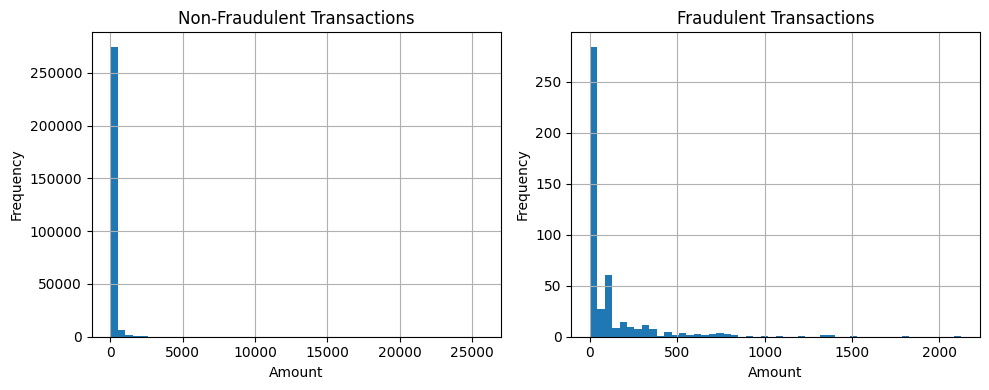

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1) # 1 row, 2 columns, 1st subplot
df[df['Class'] == 0]['Amount'].hist(bins=50)
plt.title('Non-Fraudulent Transactions')
plt.ylabel('Frequency')
plt.xlabel('Amount')
plt.subplot(1,2,2) # 1 row, 2 columns, 2nd subplot
df[df['Class'] == 1]['Amount'].hist(bins=50)
plt.title('Fraudulent Transactions')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

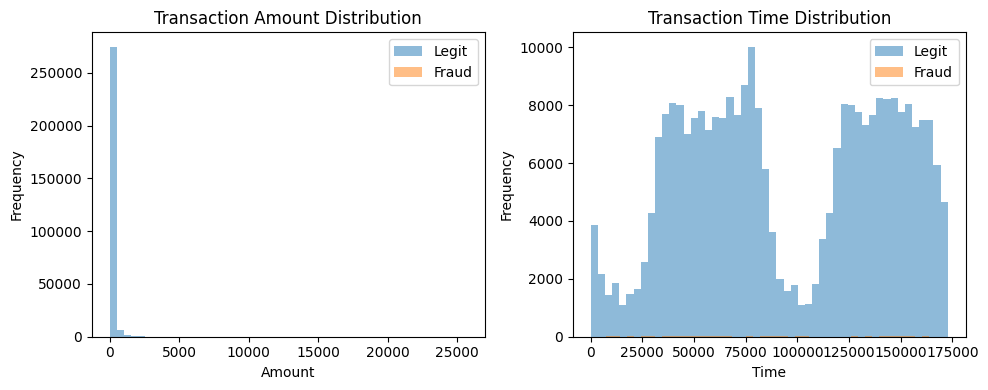

In [38]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.5, label='Legit')
plt.hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.5, label='Fraud')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.title('Transaction Amount Distribution')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(df[df['Class']==0]['Time'], bins=50, alpha=0.5, label='Legit')
plt.hist(df[df['Class']==1]['Time'], bins=50, alpha=0.5, label='Fraud')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.title('Transaction Time Distribution')
plt.legend()

plt.tight_layout()
plt.show()

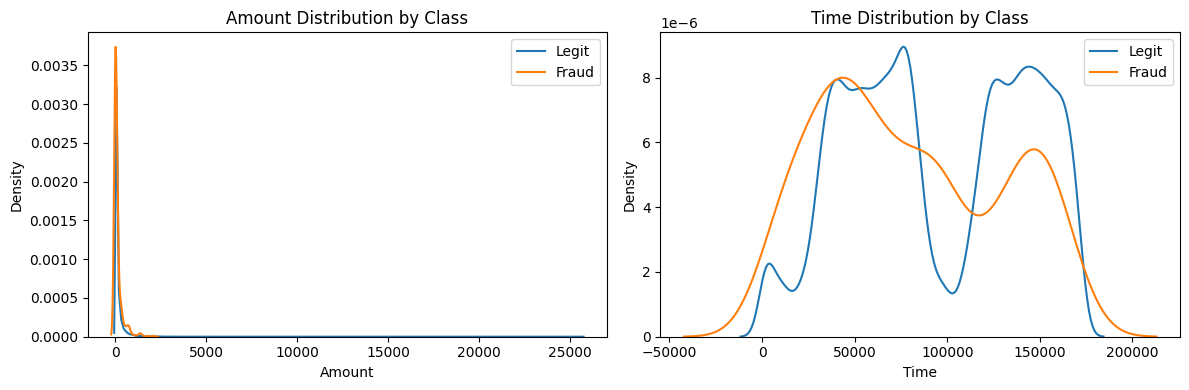

In [39]:
## Using KDE plots for better visualization
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(df[df['Class']==0]['Amount'], ax=axes[0], label='Legit')
sns.kdeplot(df[df['Class']==1]['Amount'], ax=axes[0], label='Fraud')
axes[0].set_title('Amount Distribution by Class')
axes[0].legend()

sns.kdeplot(df[df['Class']==0]['Time'], ax=axes[1], label='Legit')
sns.kdeplot(df[df['Class']==1]['Time'], ax=axes[1], label='Fraud')
axes[1].set_title('Time Distribution by Class')
axes[1].legend()

plt.tight_layout()
plt.show()

In [52]:
print("Time Range: " f"{round(min(df['Time'])/3600)} - {round(max(df['Time'])/3600)} hours")


Time Range: 0 - 48 hours


**Amount Plot**
- From plots we can observe that most transactions are of small amounts.
- Intuition: From a fraudster's perspective. If you stole someone's card details, you would amount likely test small amounts before going big, as that is less likely to trigger a bank's automatic alert system.
- Fraudsters typically start small deliberately — testing if the card works, staying under alert thresholds. (Transaction Testing)

**Time Plot**
- From time plot, we can see edges where fraud is relatively higher (-50k to 45k and 175k-200k). So,  Fraudsters prefer to strike when:
Bank staff monitoring is minimal
Victims are asleep and won't notice immediate alerts
Automated systems are less likely to have human oversight

**Note**
- For Time, 50k range in plot but not in data as KDE plots smooth the distribution by fitting a curve over the data. That smoothing sometimes extends slightly beyond the actual data range — it's just a mathematical artifact of how KDE works, not real data. Your actual Time values are 0 to 172,792 seconds. The -50k doesn't exist in reality.
This is actually an important lesson — KDE curves can bleed beyond real boundaries. Always sanity check against actual min/max values.

#### **Correlation between features**
A correlation matrix shows you how strongly each feature relates to every other feature, and crucially how strongly each feature relates to Class (your target).
Two reasons it matters here:

Feature selection — if a V feature has high correlation with Class, it's likely a strong predictor of fraud. If it's near zero, it might not help your model much.
Multicollinearity — if two input features are highly correlated with each other, they're carrying redundant information. That can hurt some models.

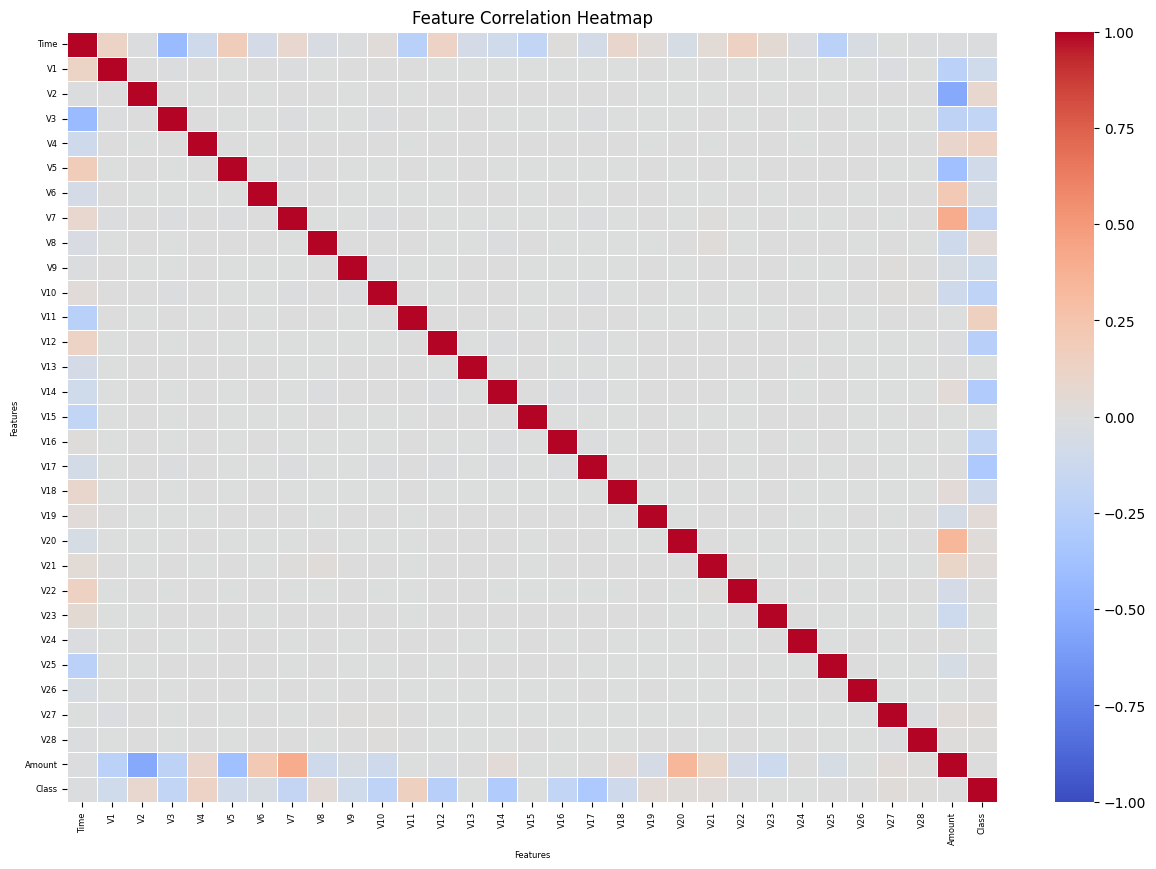

In [87]:
plt.figure(figsize=(15, 10))
ax=sns.heatmap(df.corr(),
            cmap='coolwarm',
            vmin=-1,
            fmt='.1f',
            linewidths=0.5)
ax.set_ylabel('Features', fontsize=6)
ax.set_xlabel('Features', fontsize=6)
ax.tick_params(axis='x', labelsize=6)
ax.tick_params(axis='y', labelsize=6)
plt.title('Feature Correlation Heatmap')
plt.show()

Eyeballing it, on its on for each feature correlation with Class
slightly -ve = V1,V3,V7,V1,V18
largely -ve = V10, V14, V17
slightly +ve = V2,V4, V11
Neutral=Time,V5,V6,V8,V15,V20-V28,Amount

In [80]:
for feature, corr in df.corr()['Class'].sort_values().items():
    if corr < 0.05 and corr > -0.05:
        continue
    print(f'{feature}: {corr:.4f}')

V17: -0.3135
V14: -0.2934
V12: -0.2507
V10: -0.2070
V16: -0.1872
V3: -0.1823
V7: -0.1723
V18: -0.1053
V1: -0.0945
V9: -0.0940
V5: -0.0878
V2: 0.0846
V4: 0.1293
V11: 0.1491
Class: 1.0000


#### **Key takeaways:**
Strongest negative predictors — V17, V14, V12, V10. When these go up, fraud probability drops. These will likely be your most important features.
Strongest positive predictors — V11, V4, V2. When these go up, fraud probability increases.
Notable absences — Amount and Time both fell below your 0.05 threshold. Confirms what the KDE told you — they're weak predictors on their own.
V20-V28 mostly absent — these PCA components carry little fraud signal.

In [ ]:
# Multicolinearity check
plt.figure(figsize=(10, 4))
for feature_i in df:
    if feature_i == feature_j:
        continue
    for feature_j, corr in df.corr()[feature_i].sort_values().items():
        if corr < 0.25 and corr > -0.25:
            continue
        print(f'{feature_i} - {feature_j}: {corr:.4f}')

Time - V3: -0.4221
V2 - Amount: -0.5334
V3 - Time: -0.4221
V5 - Amount: -0.3877
V7 - Amount: 0.4004
V12 - Class: -0.2507
V14 - Class: -0.2934
V17 - Class: -0.3135
V20 - Amount: 0.3407
Amount - V2: -0.5334
Amount - V5: -0.3877
Amount - V20: 0.3407
Amount - V7: 0.4004
Class - V17: -0.3135
Class - V14: -0.2934
Class - V12: -0.2507


<Figure size 1000x400 with 0 Axes>

- Multicollinearity becomes a real problem above 0.8-0.9
- Correlations aren't strong enough to cause serious issues with logistic regression
- You're early — let the model train first, then revisit feature selection if performance is poor

### Train Test Split

In [88]:
X = df.drop('Class', axis=1)
y = df['Class']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# For a project at this scale you have two options:

# Train/Test split (80/20) — simple, use cross-validation during training to tune hyperparameters instead of a separate validation set
# Train/Validation/Test split (60/20/20) — explicit validation set for hyperparameter tuning, test set for final evaluation only

# For logistic regression which has minimal hyperparameters to tune, 80/20 with cross-validation is fine. A three way split makes more sense when you get to XGBoost later which has many hyperparameters to tune.

### Feature Scaling

In [89]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Only scale the 'Amount' and 'Time' features, as the others are already PCA components
X_train[['Amount','Time']] = scaler.fit_transform(X_train[['Amount','Time']]) 
X_test[['Amount','Time']] = scaler.transform(X_test[['Amount','Time']]) 
# NOTE: 
# We use fit_transform on training data 
# BUT we use transform on test data using the same scaler fitted on training data 
# (to ensure the scaling is consistent between train and test sets
#  and NOT fit_transform on test data which would lead to 
#  Data Leakage:- Using information from the test set to influence the training 
#  process which can lead to overly optimistic performance estimates and poor generalization to new data
#  Always fit your scaler on the training data and then apply that same transformation to the test data!)

### Model Training

In [132]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=10000, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default

### Model Predictions and evaluation

In [ ]:
y_pred = model.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
# Classification report gives us precision, recall, f1-score for each class
report_dict = classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud'], output_dict=True)
cr = pd.DataFrame(report_dict)
cr


# Support is the number of actual samples of each class in your test set. 56,656 legit, 90 fraud. Confirms the imbalance.


,Not Fraud,Fraud,accuracy,macro avg,weighted avg
precision,0.999820,0.059613,0.977584,0.529716,0.998328
recall,0.977725,0.888889,0.977584,0.933307,0.977584
f1-score,0.988649,0.111732,0.977584,0.550190,0.987258
support,56656.000000,90.000000,0.977584,56746.000000,56746.000000


In [134]:
# Confusion matrix gives us the counts of true positives, true negatives, false positives, and false negatives
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, 
                     index=['Actual Not Fraud', 'Actual Fraud'], 
                     columns=['Predicted Not Fraud', 'Predicted Fraud'])
cm_df

,Predicted Not Fraud,Predicted Fraud
Actual Not Fraud,55394,1262
Actual Fraud,10,80


In [135]:
from sklearn.metrics import fbeta_score
f2 = fbeta_score(y_test, y_pred, beta=2)
print(f'F2 Score: {f2:.4f}')

F2 Score: 0.2350


### Problem: Handling Class Imbalance - Attempt 1: class_weight='balanced'

#### Problem
The dataset is heavily imbalanced - 99.8% legit, 0.17% fraud.
During training, logistic regression minimizes total loss across all samples.
With so few fraud cases, predicting "legit" every time gives very low loss,
so the model learns to ignore fraud entirely.

#### Solution Attempted - class_weight='balanced'
sklearn automatically calculates a weight for each class:
- Weight = total_samples / (n_classes * class_frequency)
- Fraud gets weighted ~600x higher than legit

This means missing a fraud case costs the model 600x more than missing a legit case.
The model is forced to pay attention to fraud examples during training.

#### Results - Before vs After

| Metric | Baseline Model | class_weight='balanced' |
|---|---|---|
| Recall (Fraud) | 0.54 | 0.89 ✅ |
| Precision (Fraud) | 0.88 | 0.06 ❌ |
| F2 Score | 0.59 | 0.24 ❌ |
| False Negatives | 41 | 10 |
| False Positives | 7 | 1262 |

#### Conclusion
Recall improved significantly but precision collapsed — pendulum swung too far.
1,262 legitimate transactions incorrectly flagged as fraud is unacceptable.
This is the precision-recall tradeoff in action.

#### Next Step
Try SMOTE — generate synthetic fraud samples to balance training data
without over-penalizing legitimate transaction misclassifications.

In [136]:
!uv add imbalanced-learn

Resolved 118 packages in 1.27s                                       
⠙ Preparing packages... (0/2)                                                   
⠙ Preparing packages... (0/2)-------------------     0 B/22.33 KiB           
⠙ Preparing packages... (0/2)------------------- 8.74 KiB/22.33 KiB          
⠙ Preparing packages... (0/2)---------- 22.33 KiB/22.33 KiB         
⠹ Preparing packages... (1/2)                                                            
⠹ Preparing packages... (1/2)-------------------     0 B/230.54 KiB          
⠹ Preparing packages... (1/2)------------------- 16.00 KiB/230.54 KiB        
⠹ Preparing packages... (1/2)------------------- 32.00 KiB/230.54 KiB        
⠹ Preparing packages... (1/2)------------------- 35.69 KiB/230.54 KiB        
⠹ Preparing packages... (1/2)------------------- 51.69 KiB/230.54 KiB        
⠹ Preparing packages... (1/2)------------------- 67.69 KiB/230.54 KiB        
⠸ Preparing packages... (1/2)------------------- 71.38 KiB/230.54 

In [138]:
# What is SMOTE:
# Remember your training data has 99.8% legit and 0.17% fraud. 
# The model barely sees fraud examples so it never learns to detect them properly.
# SMOTE fixes this by synthetically generating new fraud samples — not just copying existing ones, 
# but creating new ones by interpolating between existing fraud cases.
# Concretely — it looks at a real fraud transaction, finds its nearest fraud neighbours, 
# and creates a new synthetic fraud point somewhere between them. 
# It does this until your training set is more balanced.
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Verify balance
print(pd.Series(y_train_smote).value_counts())

Class
0    226597
1    226597
Name: count, dtype: int64


In [151]:
from sklearn.linear_model import LogisticRegression
model_smote = LogisticRegression(max_iter=10000, random_state=42, class_weight=None) # No need for class_weight when using SMOTE
model_smote.fit(X_train_smote, y_train_smote)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [152]:
# Predictions and evaluation
y_pred_smote = model_smote.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
# Classification report gives us precision, recall, f1-score for each class
report_dict = classification_report(y_test, y_pred_smote, target_names=['Not Fraud', 'Fraud'], output_dict=True)
cr = pd.DataFrame(report_dict)

cr
# Support is the number of actual samples of each class in your test set. 56,656 legit, 90 fraud. Confirms the imbalance.

,Not Fraud,Fraud,accuracy,macro avg,weighted avg
precision,0.999819,0.054274,0.975258,0.527047,0.998319
recall,0.975395,0.888889,0.975258,0.932142,0.975258
f1-score,0.987456,0.102302,0.975258,0.544879,0.986052
support,56656.000000,90.000000,0.975258,56746.000000,56746.000000


In [153]:
# Confusion matrix gives us the counts of true positives, true negatives, false positives, and false negatives
cm = confusion_matrix(y_test, y_pred_smote)
cm_df = pd.DataFrame(cm, 
                     index=['Actual Not Fraud', 'Actual Fraud'], 
                     columns=['Predicted Not Fraud', 'Predicted Fraud'])
cm_df

,Predicted Not Fraud,Predicted Fraud
Actual Not Fraud,55262,1394
Actual Fraud,10,80


In [154]:
from sklearn.metrics import fbeta_score
f2 = fbeta_score(y_test, y_pred_smote, beta=2)
print(f'F2 Score: {f2:.4f}')

F2 Score: 0.2181


### Problem: Handling Class Imbalance - Attempt 2: Fine Tuning Threshold to improve F2 Score

F2 Score less despite good recall(0.89) because of poor precision-0.05.

Default Threshold: >0.5 = fraud
if we lower thresholds more results will be classified as fraud so  recall increases as we are missing less,
Precision worsens as relevance is less, true positives reduce
So lowering threshold = recall up, precision down. And raising threshold = precision up, recall down.

So given your current SMOTE model has recall of 0.89 but precision of 0.05 — which direction should you move the threshold? 👀You said: increase threshold to boost precision => increase threshold to boost precision



**Code Notes - Threshold Tuning**
- **predict_proba(X_test)[:, 1]** — gets fraud probability for each transaction instead of binary 0/1 prediction. Two columns returned (prob of 0, prob of 1), [:, 1] grabs fraud column.
- **precision_recall_curve()** — computes precision & recall at every possible threshold automatically
- **precisions[:-1]** — drops last value sklearn adds for mathematical reasons, so array length matches thresholds
- **np.linspace(0.01, 0.99, 100)** — 100 evenly spaced thresholds between 0.01-0.99, keeps loop fast
- **(y_pred_proba >= threshold).astype(int)** — converts probabilities to 0/1 predictions at given threshold
- **np.argmax(f2_scores)** — returns *index* of best F2 score (not the value itself), used to look up corresponding threshold via threshold_samples[best_idx]
- **plt.axvline** — draws vertical line on plot at best threshold, purely visual


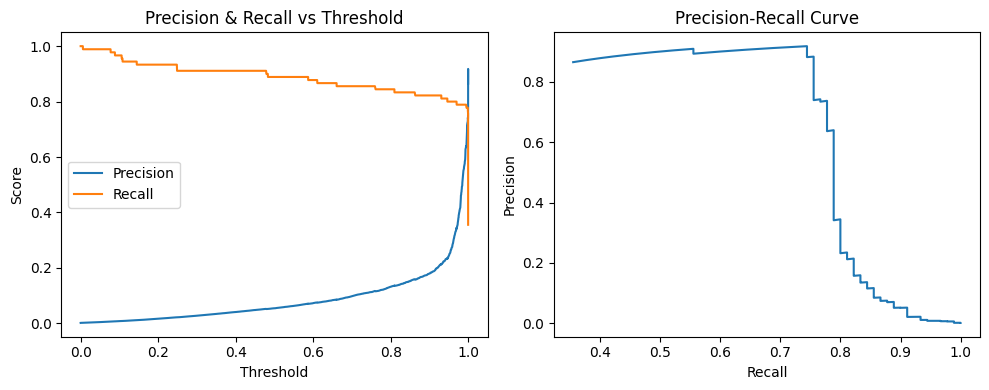

In [155]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Get probabilities instead of binary predictions
y_pred_proba = model_smote.predict_proba(X_test)[:, 1]

# Get precision, recall for all thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recalls[:-1], precisions[:-1])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

Best Threshold: 0.9900
Best F2 Score: 0.7320


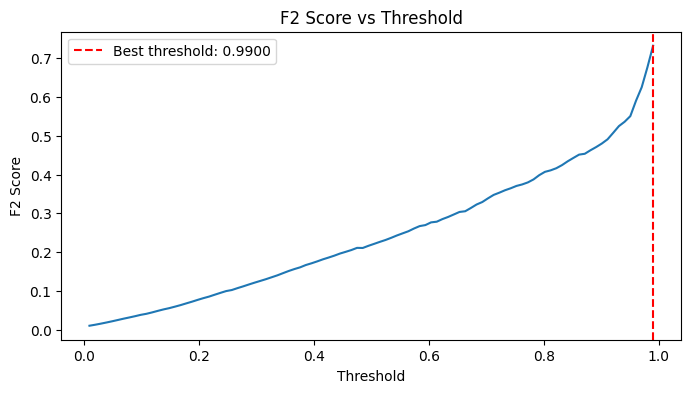

In [157]:
import numpy as np
from sklearn.metrics import fbeta_score

# Sample 100 thresholds instead of all of them
threshold_samples = np.linspace(0.01, 0.99, 100)

f2_scores = []
for threshold in threshold_samples:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    f2 = fbeta_score(y_test, y_pred_threshold, beta=2)
    f2_scores.append(f2)

best_idx = np.argmax(f2_scores)
best_threshold = threshold_samples[best_idx]
best_f2 = f2_scores[best_idx]

print(f'Best Threshold: {best_threshold:.4f}')
print(f'Best F2 Score: {best_f2:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(threshold_samples, f2_scores)
plt.xlabel('Threshold')
plt.ylabel('F2 Score')
plt.title('F2 Score vs Threshold')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold: {best_threshold:.4f}')
plt.legend()
plt.show()

## Results

In [162]:
print(f'Best Threshold: {best_threshold:.4f}')
print(f'Best F2 Score: {best_f2:.4f}')

Best Threshold: 0.9900
Best F2 Score: 0.7320


In [163]:
# Predictions and evaluation
y_pred_best = (y_pred_proba >= best_threshold).astype(int)
from sklearn.metrics import classification_report, confusion_matrix
# Classification report gives us precision, recall, f1-score for each class
report_dict = classification_report(y_test, y_pred_best, target_names=['Not Fraud', 'Fraud'], output_dict=True)
cr = pd.DataFrame(report_dict)

cr
# Support is the number of actual samples of each class in your test set. 56,656 legit, 90 fraud. Confirms the imbalance.

,Not Fraud,Fraud,accuracy,macro avg,weighted avg
precision,0.999664,0.568000,0.998714,0.783832,0.998980
recall,0.999047,0.788889,0.998714,0.893968,0.998714
f1-score,0.999356,0.660465,0.998714,0.829910,0.998818
support,56656.000000,90.000000,0.998714,56746.000000,56746.000000


In [164]:
# Confusion matrix gives us the counts of true positives, true negatives, false positives, and false negatives
cm = confusion_matrix(y_test, y_pred_best)
cm_df = pd.DataFrame(cm, 
                     index=['Actual Not Fraud', 'Actual Fraud'], 
                     columns=['Predicted Not Fraud', 'Predicted Fraud'])
cm_df

,Predicted Not Fraud,Predicted Fraud
Actual Not Fraud,56602,54
Actual Fraud,19,71


#### Performed Actions
1. Baseline Logistic Regression
2. class_weight='balanced' - penalize fraud misclassifications more heavily
3. SMOTE - synthetically generate fraud samples to balance training data
4. Threshold Tuning - find optimal classification threshold using F2 score (best: 0.99)

#### Results Summary

| Metric | Baseline | class_weight='balanced' | SMOTE + Threshold (0.99) |
|---|---|---|---|
| Recall | 0.54 | 0.89 | 0.79 |
| Precision | 0.88 | 0.06 | 0.57 |
| F2 Score | 0.59 | 0.22 | 0.73 |
| False Negatives | 41 | 10 | 19 |
| False Positives | 7 | 1262 | 54 |

#### Conclusion
SMOTE + threshold tuning gives the best balance — F2 of 0.73, 
false positives reduced from 1,262 to 54, while maintaining reasonable recall.

However, logistic regression has a fundamental limitation for this dataset —
it assumes a linear decision boundary. Fraud patterns are inherently non-linear,
which is why we cannot push F2 beyond 0.73 regardless of tuning.

#### Next Steps
- Rebuild with XGBoost — handles non-linear patterns, industry standard for fraud detection
- Target F2 > 0.85